# Rearrangement Testing - PSF occupancy

Same experiment as `rearrangement-testing.ipynb`, software pipeline only, with occupancy
called by a matched filter instead of a box sum.

One `analysis.SiteScorer` is built from the baseline images and then used everywhere:
the loading statistics, the survival check, and the rearrangement hot path.

In [1]:
from pytweezer.experiment.motmaster_client import MotMasterClient
from pytweezer.drivers.imagemX2 import ImagEMX2Camera
from pytweezer.drivers.slm import SLM
from pytweezer.drivers.thorcam import ThorCamera
from pytweezer.experiment.experiment_parameter_manager import ExpParameterManager
import pytweezer.phasemask as pm
import pytweezer.analysis as an
import numpy as np
import matplotlib.pyplot as plt

ExpParams = ExpParameterManager()

In [2]:
exp : MotMasterClient = MotMasterClient()
motcam : ThorCamera = ThorCamera(id="motcam")
slm : SLM = SLM()
hamcam : ImagEMX2Camera = ImagEMX2Camera()

Rb MotMasterClient initialised.
Thorlabs TLCamera - motcam - initialised.
SLM 1 initialised: 1024x1024 @ 8-bit, serial 7752, 40.169 degC
SLM 1 loaded LUT "C:\Program Files\Meadowlark Optics\Blink Plus\LUT Files\slm40_at852.LUT"
ImagEM X2 camera initialised.


In [3]:
exp.set_save_toggle(False)
exp.set_run_until_stopped(False)
exp.set_motmaster_experiment("RbTweezerBasic2026_2")

motcam.set_trigger_source("bulb")

hamcam.set_trigger_source("ext")
hamcam.set_external_exposure_mode()
hamcam.enable_em_gain(True)
hamcam.enable_direct_em_gain(True)
hamcam.set_sensitivity(600)
hamcam.timeout = 60*20
X0, Y0, WIDTH, HEIGHT = 110, 220, 256, 256
hamcam.set_roi(X0, WIDTH, Y0, HEIGHT)

## MOT Check

In [ ]:
img_it = 10
bg_it = 2

exp.set_iterations(bg_it)
motcam.setup_acquisition(nframes=bg_it)
motcam.start_acquisition()
exp.start_motmaster_experiment({"tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
                                "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
                                "tImgRepVCO1": ExpParams.get_parameter("rep_vco_resonance"), "tImgCoolVCO1": ExpParams.get_parameter("cool_vco_resonance"),
                                "tDelay1": 1, "tMolassesDuration": 1, "tImgCoolVVA1": 4.0, "tImgRepVVA1": 4.0, "tMOTccValue": 0.0, "tDelay2": 1,
                                "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 35000})
imgs_bg = motcam.acquire_n_frames(nframes=bg_it)

exp.set_iterations(img_it)
motcam.setup_acquisition(nframes=img_it)
motcam.start_acquisition()
exp.start_motmaster_experiment({"tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
                                "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
                                "tImgRepVCO1": ExpParams.get_parameter("rep_vco_resonance"), "tImgCoolVCO1": ExpParams.get_parameter("cool_vco_resonance"),
                                "tDelay1": 1, "tMolassesDuration": 1, "tImgCoolVVA1": 4.0, "tImgRepVVA1": 4.0, "tDelay2": 1,
                                "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 35000})
imgs = motcam.acquire_n_frames(nframes=img_it)
img_mean = imgs.mean(axis=0) - imgs_bg.mean(axis=0)

plt.imshow(img_mean, cmap='magma', vmin=0)

try:
    gaussian_params = an.fit_gaussian(img_mean)
    centre_x, centre_y = int(gaussian_params["x0"]), int(gaussian_params["y0"])
    print(f"MOT detected at (x, y): ({centre_x}, {centre_y})")
except Exception as e:
    print(f"Could not detect MOT: {e}")

## Generate Tweezer Array

In [4]:
dx, dy = 8.0, 12.0
PM = pm.OptimisationBasedPhasemaskGeneratorGPU(
                 wavelength_um=0.852,
                 focal_length_mm=17.3,
                 slm_pitch_um=17,
                 slm_res=(1024,1024),
                 input_beam_waist_mm=16,
                 fresnel_f_mm=1072,
                 blaze_dx_dy_um=(40+dx, -8+dy),
                 zernike_coeff_dict={5:1.195, 6:0.725, 7:0.970, 8:0.478, 9:-1.091, 10:0.303, 11:0.021, 12:0.072, 13:0.049})

gauss2d = lambda x, y, A, x0, y0, sx, sy, offset: (A * np.exp(-(((x - x0) ** 2) / (2 * sx ** 2) + ((y - y0) ** 2) / (2 * sy ** 2)))) + offset
A, x0, y0, sx, sy, offset = [-2.14197604e+03, -1.11443850e+01 - dx, 2.09919600e+00 - dy, 2.95002910e+03, 2.64281503e+03, 2.14239505e+03]

--- System Configuration ---
SLM Plane Width: 17.41 mm
SLM Plane Height: 17.41 mm
Focal Plane Resolution x (pixel size): 0.8467 um
Focal Plane Resolution y (pixel size): 0.8467 um
Focal Plane Width: 867.04 um
Focal Plane Height: 867.04 um
Fresnel Lens Focal Length: 1072.00 mm
Blazed Grating Displacement (dx, dy): (48.0, 4.0) um


In [5]:
W1 = np.ones((10,10))
spacing_um = 5.0

w_n, theta_n, x_n, y_n, array_shape = PM.generate_weighted_array(W1, spacing_um, init_phase_randomness=1.0, angle_deg=2.5)
w_n = (W1 * gauss2d(x_n.reshape(array_shape), y_n.reshape(array_shape), A, x0, y0, sx, sy, offset)).flatten()

terms1 = [w_n, theta_n, x_n, y_n, array_shape]
pm_array1, terms1, _ = PM.superposition_optimization(terms1, max_iter=2000, damping=0.5, verbose=True)

--- Target Generation ---
Grid: 10x10
Spacing: 5.0 um
--- Starting GPU Superposition Phase Retrieval ---
Iteration 000 | Mean-Squared Error: 1.48e-05 | Uniformity: 52.06% | Min/Max ratio: 0.011
Iteration 010 | Mean-Squared Error: 7.82e-08 | Uniformity: 83.61% | Min/Max ratio: 0.526
Iteration 020 | Mean-Squared Error: 2.45e-08 | Uniformity: 83.58% | Min/Max ratio: 0.514
Iteration 030 | Mean-Squared Error: 1.00e-08 | Uniformity: 83.36% | Min/Max ratio: 0.522
Iteration 040 | Mean-Squared Error: 1.25e-08 | Uniformity: 83.41% | Min/Max ratio: 0.529
Iteration 050 | Mean-Squared Error: 3.34e-09 | Uniformity: 83.55% | Min/Max ratio: 0.532
Iteration 060 | Mean-Squared Error: 4.50e-09 | Uniformity: 83.49% | Min/Max ratio: 0.524
Iteration 070 | Mean-Squared Error: 5.33e-09 | Uniformity: 83.62% | Min/Max ratio: 0.526
Iteration 080 | Mean-Squared Error: 4.22e-09 | Uniformity: 83.64% | Min/Max ratio: 0.525
Iteration 090 | Mean-Squared Error: 3.54e-09 | Uniformity: 83.66% | Min/Max ratio: 0.529
Itera

In [6]:
W2 = np.ones((6,6))
spacing_um = 5.0

w_n, theta_n, x_n, y_n, array_shape = PM.generate_weighted_array(W2, spacing_um, init_phase_randomness=1.0, angle_deg=2.5)
w_n = (W2 * gauss2d(x_n.reshape(array_shape), y_n.reshape(array_shape), A, x0, y0, sx, sy, offset)).flatten()

terms2 = [w_n, theta_n, x_n, y_n, array_shape]
pm_array2, terms2, _ = PM.superposition_optimization(terms2, max_iter=5000, damping=0.5, verbose=True)

--- Target Generation ---
Grid: 6x6
Spacing: 5.0 um
--- Starting GPU Superposition Phase Retrieval ---
Iteration 000 | Mean-Squared Error: 4.83e-05 | Uniformity: 70.73% | Min/Max ratio: 0.167
Iteration 010 | Mean-Squared Error: 5.32e-07 | Uniformity: 89.46% | Min/Max ratio: 0.714
Iteration 020 | Mean-Squared Error: 5.93e-07 | Uniformity: 89.93% | Min/Max ratio: 0.640
Iteration 030 | Mean-Squared Error: 4.36e-08 | Uniformity: 89.95% | Min/Max ratio: 0.675
Iteration 040 | Mean-Squared Error: 4.77e-08 | Uniformity: 89.94% | Min/Max ratio: 0.673
Iteration 050 | Mean-Squared Error: 3.60e-08 | Uniformity: 89.99% | Min/Max ratio: 0.681
Iteration 060 | Mean-Squared Error: 1.74e-08 | Uniformity: 90.06% | Min/Max ratio: 0.688
Iteration 070 | Mean-Squared Error: 4.00e-09 | Uniformity: 90.08% | Min/Max ratio: 0.688
Iteration 080 | Mean-Squared Error: 9.65e-10 | Uniformity: 90.10% | Min/Max ratio: 0.688
Iteration 090 | Mean-Squared Error: 5.13e-10 | Uniformity: 90.10% | Min/Max ratio: 0.688
Iterati

In [7]:
pm_composite = PM.superimpose([pm_array1, PM.fresnel, PM.blaze, PM.zernike])
pm_composite_uint8 = PM.transform_phase_8bit(pm_composite).get()
slm.update_mask(pm_composite_uint8)

## Baseline - Initial Array

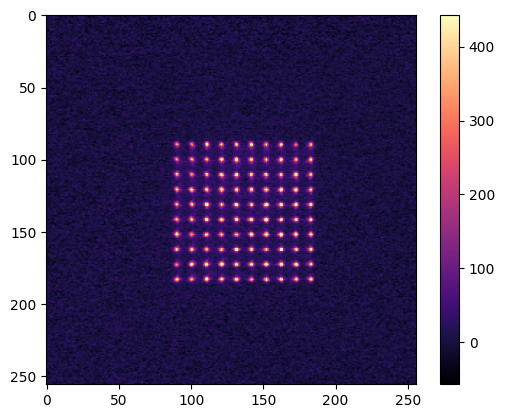

In [8]:
# Experiment and camera setup
n_iterations = 100
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
hamcam.setup_acquisition("snap", n_iterations * 2)
hamcam.start_acquisition()
exp.start_motmaster_experiment({
    "tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
    "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
    "tMolCoolVCO1": ExpParams.get_parameter("tMolCoolVCO1"), "tMolRepVCO1": ExpParams.get_parameter("tMolRepVCO1"),
    "tMolCoolVVA1": ExpParams.get_parameter("tMolCoolVVA1"), "tMolRepVVA1": ExpParams.get_parameter("tMolRepVVA1"),
    "tMolCoolVCO2": ExpParams.get_parameter("tMolCoolVCO2"), "tMolRepVCO2": ExpParams.get_parameter("tMolRepVCO2"),
    "tMolCoolVVA2": ExpParams.get_parameter("tMolCoolVVA2"), "tMolRepVVA2": ExpParams.get_parameter("tMolRepVVA2"),
    "tImgCoolVCO1": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA1": ExpParams.get_parameter("tImgCoolVVA"),
    "tImgCoolVCO2": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA2": ExpParams.get_parameter("tImgCoolVVA"),
    "tMOTShimXccValue": ExpParams.get_parameter("tMOTShimXccValue"), "tMOTShimYccValue": ExpParams.get_parameter("tMOTShimYccValue"), "tMOTShimZccValue": ExpParams.get_parameter("tMOTShimZccValue"),
    "BackgroundDrop": 1})

imgs = hamcam.acquire_n_frames(n_iterations * 2)
imgs1, imgs2 = imgs[::2], imgs[1::2]
img_average = an.tweezer_show_bg_subtracted(imgs1, imgs2, cmap='magma', show=True, vmaxfactor=0.6, show_grid=True)

Looking for trap sites...
10x10 array detected.


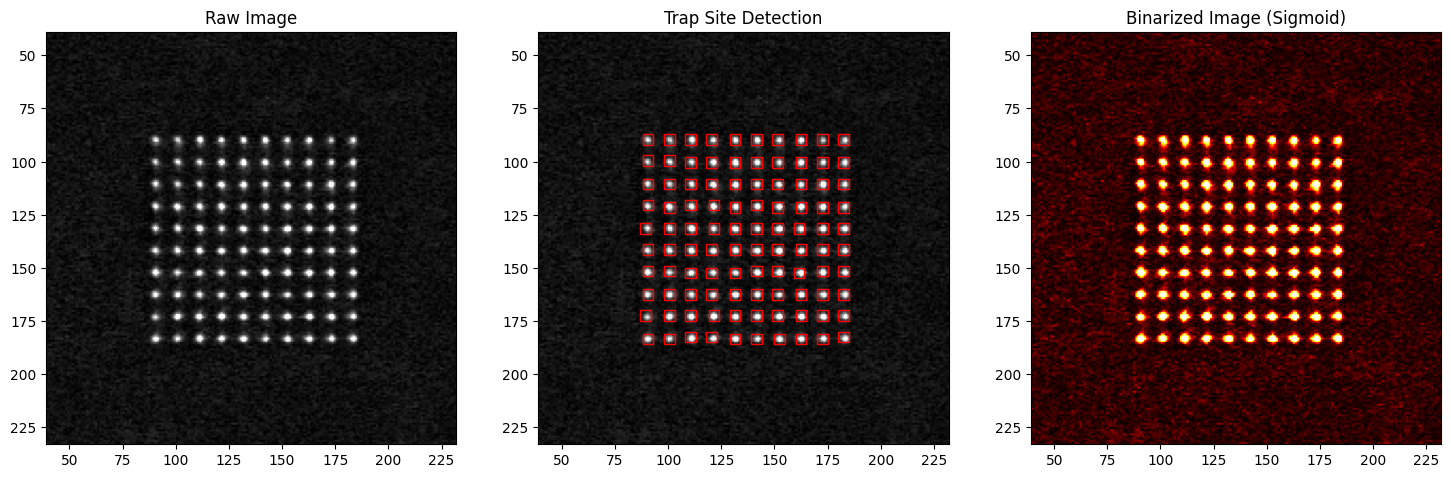

Trap (0, 0) Loading Probability : 55.00 %
Trap (0, 1) Loading Probability : 46.00 %
Trap (0, 2) Loading Probability : 58.00 %
Trap (0, 3) Loading Probability : 52.00 %
Trap (0, 4) Loading Probability : 52.00 %
Trap (0, 5) Loading Probability : 61.00 %
Trap (0, 6) Loading Probability : 59.00 %
Trap (0, 7) Loading Probability : 61.00 %
Trap (0, 8) Loading Probability : 46.00 %
Trap (0, 9) Loading Probability : 57.00 %
Trap (1, 0) Loading Probability : 52.00 %
Trap (1, 1) Loading Probability : 47.00 %
Trap (1, 2) Loading Probability : 55.00 %
Trap (1, 3) Loading Probability : 55.00 %
Trap (1, 4) Loading Probability : 61.00 %
Trap (1, 5) Loading Probability : 55.00 %
Trap (1, 6) Loading Probability : 54.00 %
Trap (1, 7) Loading Probability : 58.00 %
Trap (1, 8) Loading Probability : 57.00 %
Trap (1, 9) Loading Probability : 52.00 %
Trap (2, 0) Loading Probability : 50.00 %
Trap (2, 1) Loading Probability : 55.00 %
Trap (2, 2) Loading Probability : 55.00 %
Trap (2, 3) Loading Probability : 

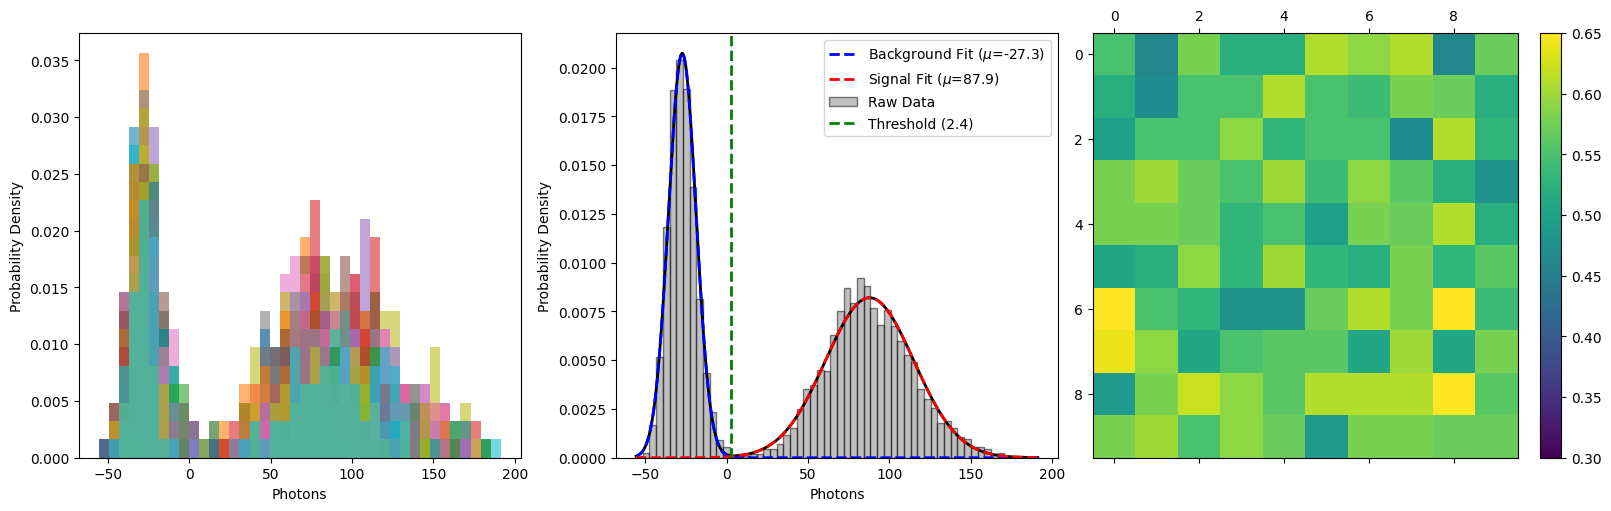

In [9]:
array_shape_1 = [10, 10]
window = 5
feature_size = 10
psf_window = 9

filtered_img_average = an.morphological_tophat_high_pass(img_average, feature_size=feature_size)
grid_positions_1, detection_threshold = an.detect_trap_sites(filtered_img_average, array_shape_1, detection_step=200)
an.visualize_results(filtered_img_average, grid_positions_1, margin=50, window_size=window, threshold=detection_threshold, vmaxfactor=0.5, bin_sharpness=20, bin_thresh_factor=0.7)

# Templates come from the raw frames - the matched filter needs no top-hat.
scorer = an.SiteScorer.from_images(imgs1, grid_positions_1, array_shape_1, window_size=psf_window)
photons, loading_probabilities, threshold_1, fidelity = an.get_array_loading_statistics(
    imgs1, grid_positions_1, array_shape_1, scorer=scorer, threshold_detection=True, binning=60)

scorer.threshold = threshold_1 * 1.1
print(f"PSF threshold {scorer.threshold:.2f} photons, detection fidelity {fidelity*100:.3f} %")

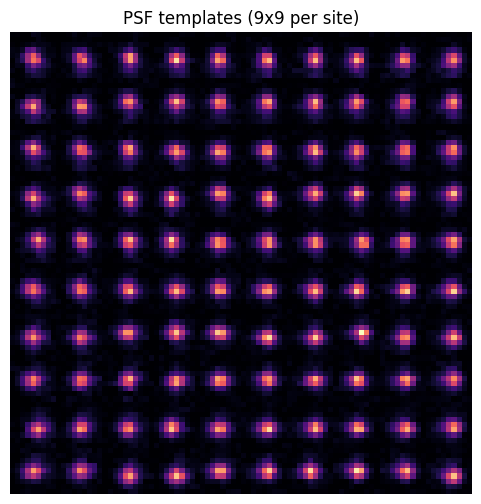

In [13]:
montage = np.block([[scorer.templates[(r, c)] for c in range(array_shape_1[1])]
                    for r in range(array_shape_1[0])])
plt.figure(figsize=(6, 6))
plt.imshow(montage, cmap='magma')
plt.title(f"PSF templates ({psf_window}x{psf_window} per site)")
plt.axis('off')
plt.show()

## Baseline Survival

In [ ]:
# Experiment and camera setup
n_iterations = 200
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
hamcam.setup_acquisition("snap", n_iterations * 2)
hamcam.start_acquisition()
exp.start_motmaster_experiment({
    "tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
    "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
    "tMolCoolVCO1": ExpParams.get_parameter("tMolCoolVCO1"), "tMolRepVCO1": ExpParams.get_parameter("tMolRepVCO1"),
    "tMolCoolVVA1": ExpParams.get_parameter("tMolCoolVVA1"), "tMolRepVVA1": ExpParams.get_parameter("tMolRepVVA1"),
    "tMolCoolVCO2": ExpParams.get_parameter("tMolCoolVCO2"), "tMolRepVCO2": ExpParams.get_parameter("tMolRepVCO2"),
    "tMolCoolVVA2": ExpParams.get_parameter("tMolCoolVVA2"), "tMolRepVVA2": ExpParams.get_parameter("tMolRepVVA2"),
    "tImgCoolVCO1": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA1": ExpParams.get_parameter("tImgCoolVVA"),
    "tImgCoolVCO2": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA2": ExpParams.get_parameter("tImgCoolVVA"),
    "tMOTShimXccValue": ExpParams.get_parameter("tMOTShimXccValue"), "tMOTShimYccValue": ExpParams.get_parameter("tMOTShimYccValue"), "tMOTShimZccValue": ExpParams.get_parameter("tMOTShimZccValue"),
    "BackgroundDrop": 0})

imgs = hamcam.acquire_n_frames(n_iterations * 2)
imgs1, imgs2 = imgs[::2], imgs[1::2]

In [ ]:
before = np.array([scorer.occupancy(img) for img in imgs1])
after = np.array([scorer.occupancy(img) for img in imgs2])
baseline_survival_probability = (before & after).sum() / before.sum()

print(f"Initial filling: {before.mean()*100:.1f} %")
print(f"Baseline survival probability: {baseline_survival_probability:.4f}")

## Rearrangement Init

In [14]:
# The scorer is already in photons; threshold_count is only for the coordinator's
# fallback path, which still works in counts.
threshold_count = an.convert_photons_to_counts(threshold_1) * 1.1
print(f"PSF threshold {scorer.threshold:.2f} photons ({threshold_count:.1f} counts)")

PSF threshold 2.60 photons (2368.7 counts)


In [15]:
import asyncio
from pytweezer.coordinators.rearrangement import Rearrangement

coordinator = Rearrangement({"camera": hamcam, "slm": slm}, {})

data1, array_shape1 = np.stack(terms1[:4]), terms1[4]
data2, array_shape2 = np.stack(terms2[:4]), terms2[4]
await asyncio.to_thread(
    coordinator.initialise,
    data1, data2, array_shape1, array_shape2,
    d0=1.0, fps=1/(1e-6), threshold=threshold_count,
    grid_positions=grid_positions_1, roi=[X0, Y0, WIDTH, HEIGHT], profile="linear",
    detector=scorer
)

--- System Configuration ---
SLM Plane Width: 17.41 mm
SLM Plane Height: 17.41 mm
Focal Plane Resolution x (pixel size): 0.8467 um
Focal Plane Resolution y (pixel size): 0.8467 um
Focal Plane Width: 867.04 um
Focal Plane Height: 867.04 um
Fresnel Lens Focal Length: 1072.00 mm
Blazed Grating Displacement (dx, dy): (48.0, 4.0) um
Phasemask generator initialised.
Camera configured for rearrangement (roi=%s). [110, 220, 256, 256]
Occupancy via PSF detector (window 9, threshold 2.6).
Rearrangement node initialised.


## Rearrangement Exp

In [16]:
import time

# Experiment and camera setup
n_iterations = 1
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
exp.set_save_toggle(False)
exp.set_run_until_stopped(False)

{'ok': True,
 'command': 'interface_method',
 'method': 'set_run_until_stopped',
 'state': 'accepted'}

In [17]:
N_iterations = 100  # adjust before running
imgs_software = []
err_indices = []
timings_log = []

for it in range(N_iterations):
    print(f"Running experiment iteration {it+1} / {N_iterations}")
    rearrangement_task = asyncio.create_task(asyncio.to_thread(coordinator.arm_rearrangement))

    time.sleep(0.1)
    exp.start_motmaster_experiment({
    "tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
    "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
    "tMolCoolVCO1": ExpParams.get_parameter("tMolCoolVCO1"), "tMolRepVCO1": ExpParams.get_parameter("tMolRepVCO1"),
    "tMolCoolVVA1": ExpParams.get_parameter("tMolCoolVVA1"), "tMolRepVVA1": ExpParams.get_parameter("tMolRepVVA1"),
    "tMolCoolVCO2": ExpParams.get_parameter("tMolCoolVCO2"), "tMolRepVCO2": ExpParams.get_parameter("tMolRepVCO2"),
    "tMolCoolVVA2": ExpParams.get_parameter("tMolCoolVVA2"), "tMolRepVVA2": ExpParams.get_parameter("tMolRepVVA2"),
    "tImgCoolVCO1": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA1": ExpParams.get_parameter("tImgCoolVVA"),
    "tImgCoolVCO2": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA2": ExpParams.get_parameter("tImgCoolVVA"),
    "tMOTShimXccValue": ExpParams.get_parameter("tMOTShimXccValue"), "tMOTShimYccValue": ExpParams.get_parameter("tMOTShimYccValue"), "tMOTShimZccValue": ExpParams.get_parameter("tMOTShimZccValue"),
    "BackgroundDrop": 0})
    img0, img1, timings = await rearrangement_task
    print("Images acquired from rearrangement node.")

    if img1.sum() == 0:
        print(f"Empty image received at iteration {it+1}. Discarding...")
        err_indices.append(it)
    else:
        imgs_software.append([img0, img1])
    timings_log.append(timings)

mean_rearrangement_time_ms = np.mean([t['total_rearrangement_ms'] for t in timings_log])
mean_calc_upload_time_ms = np.mean([t['calculation_and_upload_ms'] for t in timings_log])
mean_nframes = np.mean([t['n_frames'] for t in timings_log])
mean_occupancy_ms = np.mean([t['occupancy_extraction_ms'] for t in timings_log])
print(f"Average total rearrangement time = {mean_rearrangement_time_ms:.2f} ms")
print(f"Average number of frames = {mean_nframes:.2f}")
print(f"Average occupancy extraction = {mean_occupancy_ms:.4f} ms")
print(f"Average total speed = {mean_rearrangement_time_ms / mean_nframes:.2f} ms/frame")
print(f"Average calculation and upload speed = {mean_calc_upload_time_ms / mean_nframes:.4f} ms/frame")

Running experiment iteration 1 / 100
Reset-image acquisition failed; returning zeros.
Rearrangement complete: 12 frames, 38.2897ms total (occupancy 0.1231ms, calculation+upload 38.1666ms).
Images acquired from rearrangement node.
Empty image received at iteration 1. Discarding...
Running experiment iteration 2 / 100
Rearrangement complete: 11 frames, 11.4166ms total (occupancy 0.1229ms, calculation+upload 11.2937ms).
Images acquired from rearrangement node.
Running experiment iteration 3 / 100
Rearrangement complete: 11 frames, 11.1251ms total (occupancy 0.1198ms, calculation+upload 11.0053ms).
Images acquired from rearrangement node.
Running experiment iteration 4 / 100
Rearrangement complete: 12 frames, 12.2446ms total (occupancy 0.1217ms, calculation+upload 12.1229ms).
Images acquired from rearrangement node.
Running experiment iteration 5 / 100
Rearrangement complete: 11 frames, 11.3215ms total (occupancy 0.1268ms, calculation+upload 11.1947ms).
Images acquired from rearrangement n

### Per-frame cost

A shot costs a fixed amount plus a per-frame amount:

    total = fixed + per_frame * n_frames

The fixed part is everything that happens once however long the sequence is - starting
the writer thread, generating frame 0 before anything can be uploaded, setting up the
queue. The per-frame part is the marginal cost of one more frame, which is what the
`PANEL_PERIOD_S` pacing floor bounds.

Dividing `total / n_frames` mixes the two, so it reads worse on short sequences and
better on long ones purely because the fixed part is shared out differently - the same
hardware can report anywhere from ~1.25 to ~0.9 ms/frame just by moving atoms further.
Fitting a straight line through (n_frames, total) separates them: the slope is the real
per-frame cost and the intercept is the per-shot overhead. Comparisons between runs
should use the slope.

This needs a spread of frame counts to fit. If every shot used the same n_frames the
slope is meaningless, which the check below reports.

  calculation + upload:   2.17 ms fixed + 0.842 ms/frame (residual sd 2.622 ms)
                 total:   2.33 ms fixed + 0.841 ms/frame (residual sd 2.619 ms)

ratio total/n_frames = 1.055 ms/frame over n_frames 6-15


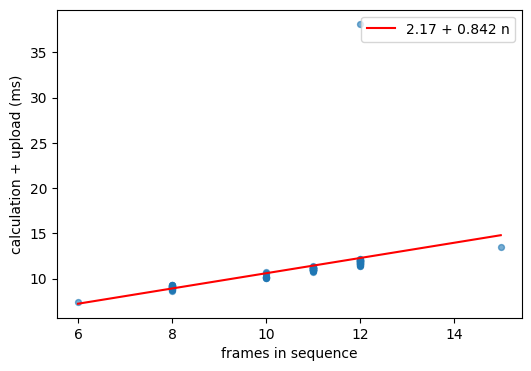

In [18]:
n_frames = np.array([t['n_frames'] for t in timings_log], dtype=float)
calc_upload_ms = np.array([t['calculation_and_upload_ms'] for t in timings_log])
total_ms = np.array([t['total_rearrangement_ms'] for t in timings_log])

if len(np.unique(n_frames)) < 2:
    print(f"All shots used {n_frames[0]:.0f} frames - cannot separate fixed from per-frame cost.")
else:
    for label, y in (("calculation + upload", calc_upload_ms), ("total", total_ms)):
        per_frame, fixed = np.polyfit(n_frames, y, 1)
        residual = y - (fixed + per_frame * n_frames)
        print(f"{label:>22}: {fixed:6.2f} ms fixed + {per_frame:.3f} ms/frame "
              f"(residual sd {residual.std():.3f} ms)")
    print(f"\nratio total/n_frames = {(calc_upload_ms / n_frames).mean():.3f} ms/frame "
          f"over n_frames {n_frames.min():.0f}-{n_frames.max():.0f}")

    plt.figure(figsize=(6, 4))
    plt.scatter(n_frames, calc_upload_ms, s=18, alpha=0.6)
    fit_x = np.array([n_frames.min(), n_frames.max()])
    per_frame, fixed = np.polyfit(n_frames, calc_upload_ms, 1)
    plt.plot(fit_x, fixed + per_frame * fit_x, 'r-',
             label=f"{fixed:.2f} + {per_frame:.3f} n")
    plt.xlabel("frames in sequence")
    plt.ylabel("calculation + upload (ms)")
    plt.legend()
    plt.show()

## Results

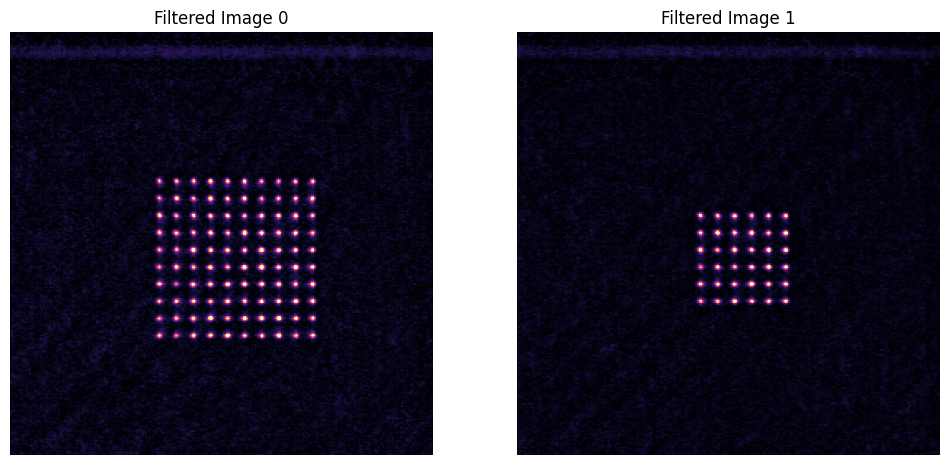

In [19]:
tot_imgs = np.array(imgs_software)

imgs0 = tot_imgs[:, 0, :, :]
imgs1 = tot_imgs[:, 1, :, :]

imgs0_mean = imgs0.mean(axis=0)
imgs1_mean = imgs1.mean(axis=0)

imgs0_mean_filtered = an.morphological_tophat_high_pass(imgs0_mean, feature_size=feature_size)
imgs1_mean_filtered = an.morphological_tophat_high_pass(imgs1_mean, feature_size=feature_size)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(imgs0_mean_filtered, cmap='magma', vmax=0.6*imgs0_mean_filtered.max())
plt.title('Filtered Image 0')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(imgs1_mean_filtered, cmap='magma', vmax=0.6*imgs1_mean_filtered.max())
plt.title('Filtered Image 1')
plt.axis('off')

plt.show()

In [59]:
hamcam.close()
slm.close()
motcam.close()